# Plotting with Julia

- [Plots.jl](https://github.com/JuliaPlots/Plots.jl): powerful and convenient visualization mwith ultiple backends. See also [Plots.jl docs](http://docs.juliaplots.org/latest/)
- [PyPlot.jl](https://github.com/JuliaPy/PyPlot.jl): `matplotlib` in Julia. See also [matplotlib docs](https://matplotlib.org/stable/index.html)
- [Makie.jl](https://github.com/JuliaPlots/Makie.jl): a data visualization ecosystem for the Julia programming language, with high performance and extensibility. See also [Makie.jl docs](https://makie.juliaplots.org/stable/tutorials/)

In [1]:
using Plots

In [2]:
f(x) = sin(sin(x) + 1)

f (generic function with 1 method)

In [3]:
xs = 0.0:0.1:4pi

0.0:0.1:12.5

In [4]:
ys = f.(xs)

126-element Vector{Float64}:
 0.8414709848078965
 0.8911317861333838
 0.9315560826328598
 0.9623501813639228
 0.9835960588100923
 0.9958285928692856
 0.9999810651039218
 0.9973058625146969
 0.9892793281920914
 0.9775002586636391
 0.9635907245418334
 0.9491060405792519
 0.9354583090330478
 ⋮
 0.08058400266618558
 0.12422607398385804
 0.17624596561456454
 0.2357754296709225
 0.30169969146476955
 0.3726498227859906
 0.44701633928081586
 0.5229877415734713
 0.5986147895910303
 0.6718978181818495
 0.7408908673778799
 0.8038134083524772

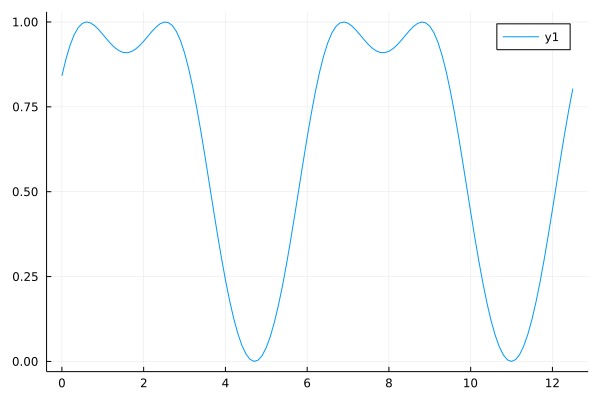

In [5]:
# Line plots connect the data points
plot(xs, ys)

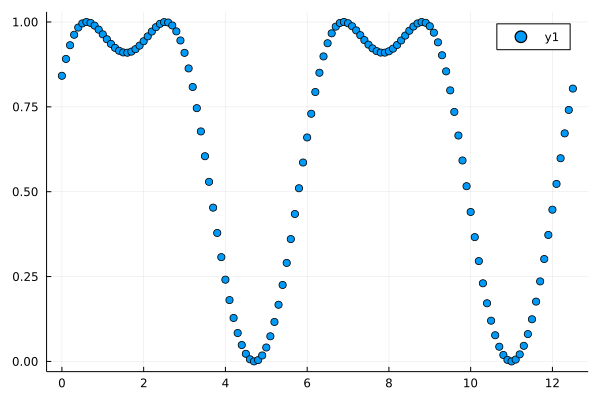

In [6]:
# scatter plots show the data points only
scatter(xs, ys)

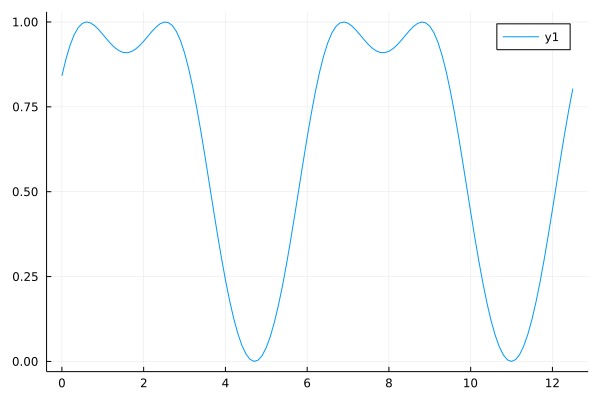

In [7]:
# you can plot functions directly
plot(f, xs)

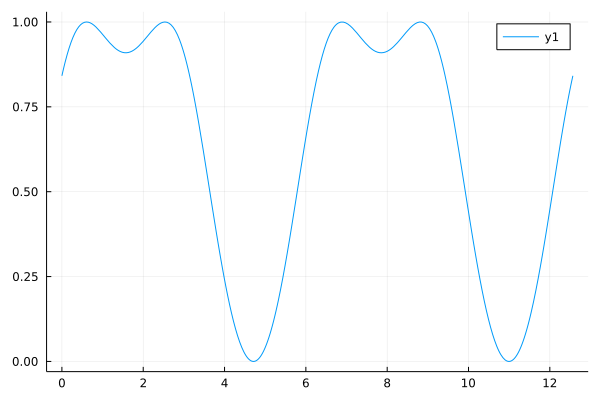

In [8]:
# plot a function with a range
plot(f, 0.0, 4pi)

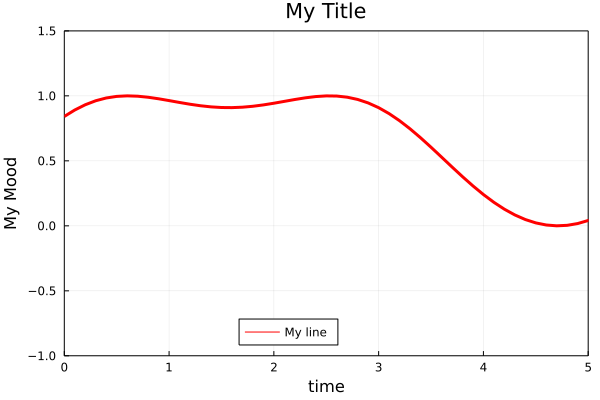

In [9]:
# Customizations
plot(f, xs, 
     label="My line", legend=:bottom, 
     title="My Title",  line=(:red, 3),
     xlim = (0.0, 5.0), ylim = (-1.0, 1.5),
     xlabel="time", ylabel="My Mood", border=:box)

Multiple series: each row is one observation; each column is a variable.

In [10]:
f2(x) = cos(cos(x) + 1)

f2 (generic function with 1 method)

In [11]:
y2 = f2.(xs)

126-element Vector{Float64}:
 -0.4161468365471424
 -0.4115989626245442
 -0.39793995394658593
 -0.37513292022522066
 -0.3431464165959406
 -0.3019964901426669
 -0.251799567898706
 -0.1928303905605429
 -0.12557796104012148
 -0.050791777273393006
  0.030489295156121407
  0.11693208142980759
  0.2069325218043063
  ⋮
  0.17637792096399765
  0.0873799893855719
  0.002506694401771309
 -0.07672453661400838
 -0.14907836040441386
 -0.21361508187450767
 -0.2696770419201289
 -0.31685309804973233
 -0.35492824797420097
 -0.38382617162484306
 -0.40355226239464964
 -0.41414381043612153

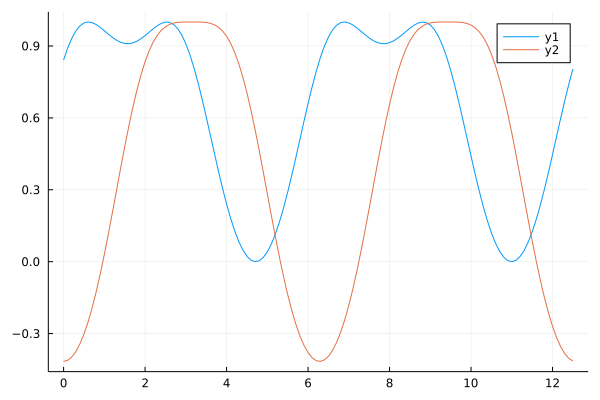

In [12]:
plot(xs, [ys y2])

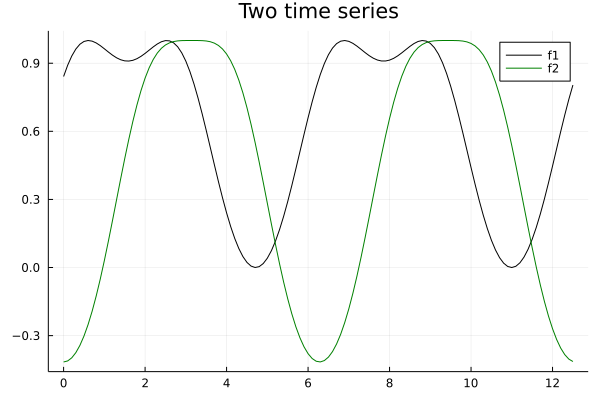

In [13]:
# Plotting two functions with customizations
plot(xs, [f, f2], label=["f1" "f2"], lc=[:black :green], title="Two time series")

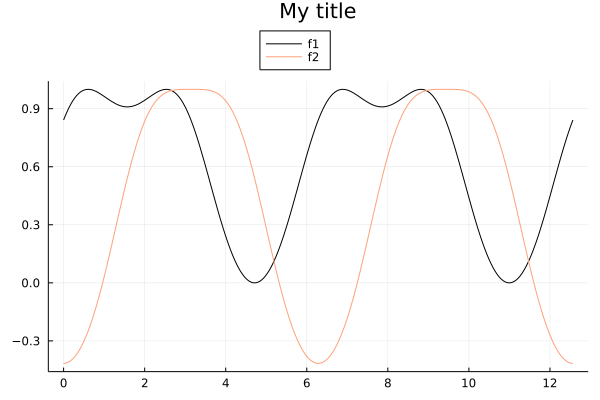

In [14]:
# Building the plot in multiple steps
# in the object-oriented way (recommended)

xMin = 0.0
xMax = 4.0π
p1 = plot(f, xMin, xMax, label="f1", lc=:black)
plot!(p1 , f2, xMin, xMax, label="f2", lc=:lightsalmon)
plot!(p1, title = "My title", legend=:outertop)

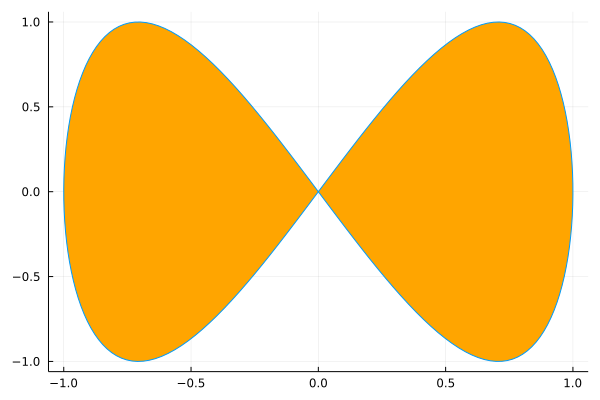

In [15]:
# Parametric plot
xₜ(t) = sin(t)
yₜ(t) = sin(2t)

plot(xₜ, yₜ, 0, 2π, leg=false, fill=(0,:orange))

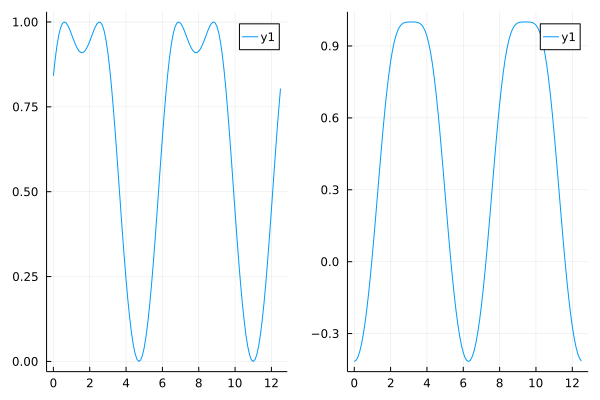

In [16]:
# Subplots
p1 = plot(f, xs)
p2 = plot(f2, xs)
plot(p1, p2)

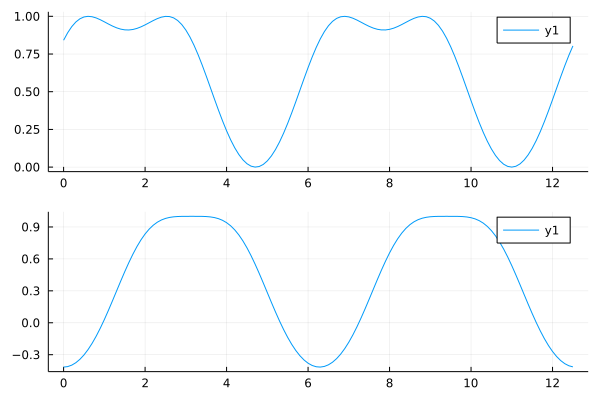

In [17]:
plot(p1, p2, layout=(2, 1))

## Vector field

### `Plots.jl`

```julia
# Quiver plot
quiver(vec(x2d), vec(y2d), quiver=(vec(vx2d), vec(vy2d))
# Or this
quiver(x2d, y2d, quiver=f) # Where f = (x,y) -> (vx, vy)
```

See also: Using quiver plots in [Plots.jl](https://ntumito.gitlab.io/wen-wei-tseng/learn-julia-visualization/plotsjl-gallery.html#quiver-plots)

### `PyPlot.jl`:

```julia
quiver(X2d,Y2d,U2d,V2d)
```

See also: Using quiver plots in [PyPlot.jl](https://ntumito.gitlab.io/wen-wei-tseng/learn-julia-visualization/pyplot-gizmaa.html#quiver-plots) and [matplotlib: quiver plot](https://matplotlib.org/stable/gallery/images_contours_and_fields/quiver_demo.html#sphx-glr-gallery-images-contours-and-fields-quiver-demo-py)

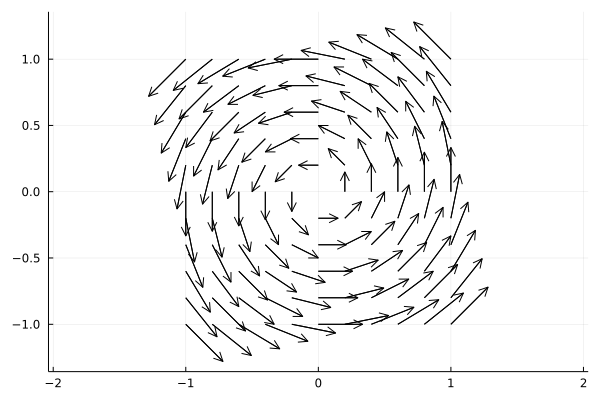

In [18]:
using Plots

# ∇ = \nabla <TAB>
function ∇f(x, y; scale=hypot(x, y)^0.5 * 3)
    return [-y, x] ./ scale
end

# x mesh and y mesh
r = -1.0:0.2:1.0
xx = [x for y in r, x in r]
yy = [y for y in r, x in r]

quiver(xx, yy, quiver=∇f, aspect_ratio=:equal, line=(:black))